<a href="https://colab.research.google.com/github/Lucas-Laods/Pos_Dados_Analytics/blob/main/An%C3%A1lise_de_Dados_e_Boas_Pr%C3%A1ticas_colab(4052026000053).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Lucas Alves Osório da Silva

**Matrícula:** 4052026000053

**Dataset:** [S&P 500 Historical Daily Prices (1980–2026)](https://www.kaggle.com/datasets/ibrahimshahrukh/s-and-p-500-historical-data-1980-2026)



 **------**

# Descrição do Problema

O dataset S&P 500 Historical Daily Prices representa um dos principais índices de ações do mundo, o S&P 500, que mapeia o desempenho das 500 maiores empresas de capital aberto dos EUA. O objetivo principal é verificar se um investidor que investe no longo prazo obteve rendimentos positivos ao longo dos anos, apesar das crises pelas quais o mercado passou, como a crise da Covid-19.

## Hipóteses do Problema

As hipóteses que tracei são as seguintes:

1. **Existe correlação entre o volume das transações e o retorno diário?**

2. **Um investidor que aplica na S&P500 no longo prazo tende a ter mais ganhos que perdas?**

3. **A covid-19 teve um grande impacto na bolsa? Ela foi a pior crise do mercado historicamente??**

## Tipo de Problema

Este é um problema de **classificação supervisionada**. Dado um conjunto de características (Abertura e fechamento da bolsa, alta e baixa do período), o objetivo é prever se o investimento é uma opção de rendimento consistente ao longo do tempo e se o retorno diário será positivo ou negativo.

## Seleção de Dados

O dataset utilizado foi disponibilizado pela Kaggle, uma comunidade de cientidades de dados e entusiastas de machine learning.

## Atributos do Dataset

O dataset S&P 500 Historical Daily Prices (1980–2026) contém dados diários que vão de 02/01/1980 a 30/01/2026. A base foi estruturada apresentando os cinco dados fundamentais utilizados na análise de mercados financeiros, o OHLCV, que em português significa:

- ***Open (Abertura)*** (O primeiro preço de negociação no período)
- ***High (Máxima)*** (O maior preço registrado no período)
- ***Low (Mínima)*** (O menor preço registrado no período)
- ***Close (Fechamento)*** (O último preço de negociação no período)
- ***Volume*** (Volume: A quantidade total de ativos negociados no período)

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub # Importando a biblioteca kagglehub
#from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [2]:
# Caminho do dataset (aqui, ele fica disponível nesse método)
#iris = load_iris()
path = kagglehub.dataset_download("ibrahimshahrukh/s-and-p-500-historical-data-1980-2026")

100%|██████████| 919k/919k [00:00<00:00, 84.7MB/s]

Extracting files...


In [3]:
# guardo o dataset em um dataframe

df = pd.read_csv(path + "/sp500_historical_1980_2026.csv")

In [4]:
# primeiras linhas
df.head()

,Date,Year,Month,Quarter,DayOfWeek,Open,High,Low,Close,Volume,...,MACD,MACD_Signal,MACD_Hist,RSI_14,BB_Upper,BB_Mid,BB_Lower,BB_Width,ATR_14,OBV
0,1980-01-02,1980,1,1,Wednesday,107.94,108.43,105.29,105.76,40610000,...,0.00,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,3.14,0.0
1,1980-01-03,1980,1,1,Thursday,105.76,106.08,103.26,105.22,50480000,...,-0.04,-0.0080,-0.0320,0.00,NaN,NaN,NaN,NaN,3.12,-50480000.0
2,1980-01-04,1980,1,1,Friday,105.22,107.08,105.09,106.52,39130000,...,0.03,-0.0004,0.0304,15.62,NaN,NaN,NaN,NaN,3.04,-11350000.0
3,1980-01-07,1980,1,1,Monday,106.52,107.80,105.80,106.81,44500000,...,0.10,0.0197,0.0803,18.68,NaN,NaN,NaN,NaN,2.96,33150000.0
4,1980-01-08,1980,1,1,Tuesday,106.81,109.29,106.29,108.95,53390000,...,0.34,0.0837,0.2563,36.84,NaN,NaN,NaN,NaN,2.97,86540000.0


# Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset S&P500, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## Total e Tipo das Instâncias

O dataset S&P500 possui 11.615 instâncias (observações) e 30 colunas. Os tipos de dados são inteiros, decimais e objeto.

In [5]:
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 11615

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11615 entries, 0 to 11614
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   11615 non-null  object 
 1   Year                   11615 non-null  int64  
 2   Month                  11615 non-null  int64  
 3   Quarter                11615 non-null  int64  
 4   DayOfWeek              11615 non-null  object 
 5   Open                   11615 non-null  float64
 6   High                   11615 non-null  float64
 7   Low                    11615 non-null  float64
 8   Close                  11615 non-null  float64
 9   Volume                 11615 non-null  int64  
 10  Daily_Return_Pct       11614 non-null  float64
 11  Cumulative_Return_Pct  11615 non-null  float64
 12  Annual_Return_Pct      11615 non-null  float64
 13  Volatility_21D         11594 non-null  float64
 14 

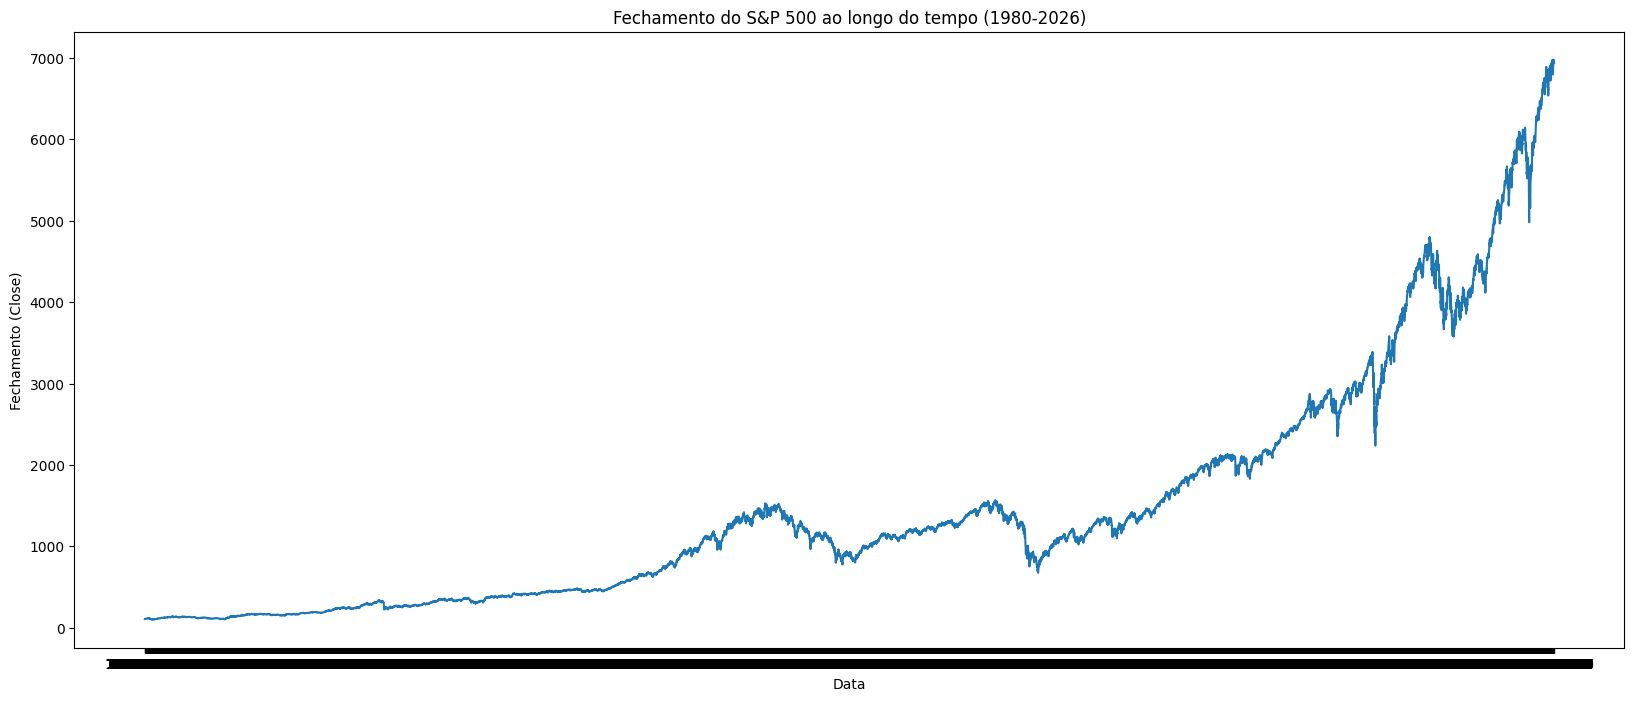

In [6]:
# gráfico de barras simples
plt.figure(figsize=(20, 8))
sns.lineplot(x='Date', y='Close', data=df)  # gráfico de linha
plt.title('Fechamento do S&P 500 ao longo do tempo (1980-2026)')
plt.xlabel('Data')
plt.ylabel('Fechamento (Close)')
plt.show()

O gráfico de linha mostra a evolução da bolsa ao longo do tempo. Fica claro que ao decorrer dos anos, a bolsa valorizou, apesar de alguns momentos de queda.

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [7]:
# estatísticas descritivas básicas do dataset
df.describe()

,Year,Month,Quarter,Open,High,Low,Close,Volume,Daily_Return_Pct,Cumulative_Return_Pct,...,MACD,MACD_Signal,MACD_Hist,RSI_14,BB_Upper,BB_Mid,BB_Lower,BB_Width,ATR_14,OBV
count,11615.000000,11615.000000,11615.000000,11615.000000,11615.000000,11615.000000,11615.000000,1.161500e+04,11614.000000,11615.000000,...,11615.000000,11615.000000,11615.000000,11614.000000,11596.000000,11596.000000,11596.000000,11596.000000,11615.000000,1.161500e+04
mean,2002.509858,6.528455,2.509944,1474.414702,1482.873987,1465.373392,1474.721551,2.041607e+09,0.042384,1294.403924,...,4.091376,4.083084,0.008292,54.301871,1518.482708,1471.366664,1424.250554,0.064904,18.731418,4.188160e+11
std,13.302305,3.436180,1.116304,1456.390092,1463.679286,1448.456668,1456.591282,1.948619e+09,1.123986,1377.261042,...,21.780615,20.434851,6.733803,11.559052,1493.272324,1448.378880,1404.541573,0.042560,21.144166,5.093311e+11
min,1980.000000,1.000000,1.000000,98.220000,99.580000,94.230000,98.220000,0.000000e+00,-20.466900,-7.130000,...,-237.020000,-198.638700,-64.503800,0.000000,104.690000,101.300000,95.930000,0.009100,1.060000,-4.453700e+08
25%,1991.000000,4.000000,2.000000,379.465000,381.405000,377.520000,379.465000,1.946550e+08,-0.450425,258.800000,...,-1.330000,-1.156250,-1.441150,46.090000,390.140000,380.285000,369.785000,0.039400,3.545000,3.169312e+10
50%,2002.000000,7.000000,3.000000,1125.780000,1132.920000,1119.290000,1125.860000,1.356000e+09,0.059750,964.540000,...,2.180000,2.044000,0.043000,55.210000,1160.590000,1124.095000,1088.155000,0.054700,13.240000,9.994213e+10
75%,2014.000000,10.000000,4.000000,1914.795000,1928.270000,1898.045000,1916.615000,3.680410e+09,0.572775,1712.230000,...,10.730000,10.265750,1.477650,62.797500,1972.965000,1924.150000,1847.557500,0.077600,22.680000,8.772504e+11
max,2026.000000,12.000000,4.000000,7002.000000,7002.280000,6963.460000,6978.600000,1.145623e+10,11.580000,6498.520000,...,121.080000,95.567500,60.897000,86.690000,7026.700000,6929.120000,6838.370000,0.555200,198.150000,1.723267e+12


### Média

A média é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações. É sensível a valores extremos (outliers).

In [8]:
# média dos atributos numéricos do dataset
df.describe().loc['mean']

,mean
Year,2.002510e+03
Month,6.528455e+00
Quarter,2.509944e+00
Open,1.474415e+03
High,1.482874e+03
Low,1.465373e+03
Close,1.474722e+03
Volume,2.041607e+09
Daily_Return_Pct,4.238362e-02
Cumulative_Return_Pct,1.294404e+03


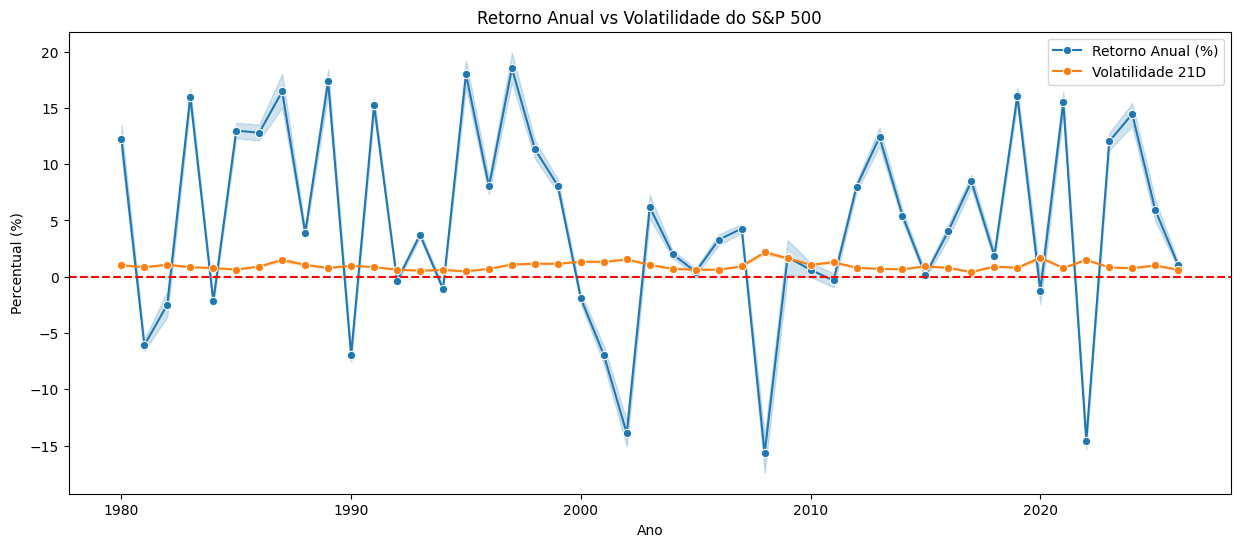

In [9]:
# Qual gráfico seria interessante usar pra mostrar a média?
# Vamos analisar o gráfico de linha para as váriaveis de retorno anual e volatilidade.
# Assim, iremos verificar os ganhos e perdas de cada ano e sua relação com a volatilidade.

plt.figure(figsize=(15, 6))

# Retorno anual
sns.lineplot(x='Year', y='Annual_Return_Pct', data=df, label='Retorno Anual (%)', marker='o')

# Volatilidade
sns.lineplot(x='Year', y='Volatility_21D', data=df, label='Volatilidade 21D', marker='o')

plt.title('Retorno Anual vs Volatilidade do S&P 500')
plt.xlabel('Ano')
plt.ylabel('Percentual (%)')
plt.axhline(0, color='red', linestyle='--')  # linha de referência no zero
plt.legend()
plt.show()

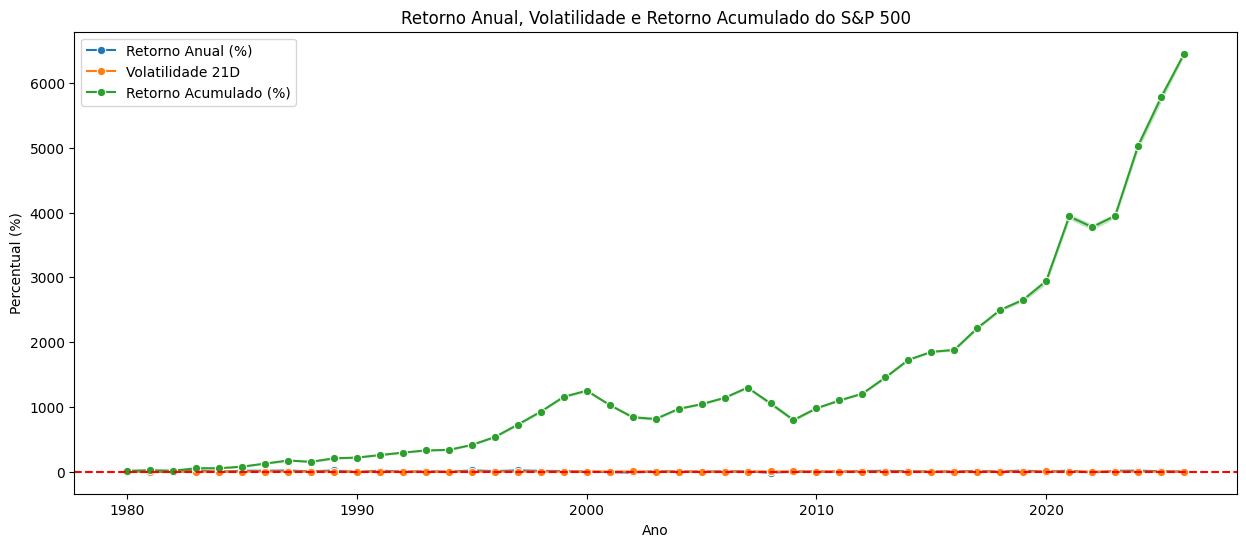

In [10]:
#Esse novo gráfico será apresentado para mostrar novas análises, visto que a oscilação do retorno anual
#do gráfico anterior pode levar a conclusões erradas.

plt.figure(figsize=(15, 6))

# Retorno anual
sns.lineplot(x='Year', y='Annual_Return_Pct', data=df, label='Retorno Anual (%)', marker='o')

# Volatilidade
sns.lineplot(x='Year', y='Volatility_21D', data=df, label='Volatilidade 21D', marker='o')

# Retorno acumulado
sns.lineplot(x='Year', y='Cumulative_Return_Pct', data=df, label='Retorno Acumulado (%)', marker='o')

plt.title('Retorno Anual, Volatilidade e Retorno Acumulado do S&P 500')
plt.xlabel('Ano')
plt.ylabel('Percentual (%)')
plt.axhline(0, color='red', linestyle='--')
plt.legend()
plt.show()

### Desvio Padrão

O desvio padrão é uma medida de dispersão que quantifica a quantidade de variação ou dispersão de um conjunto de valores. Um desvio padrão baixo indica que os pontos de dados tendem a estar próximos da média do conjunto, enquanto um desvio padrão alto indica que os pontos de dados estão espalhados por uma faixa maior de valores. Ele é a raiz quadrada da variância.

In [11]:
# desvio padrão dos atributos numéricos do dataset
df.describe().loc['std']

,std
Year,1.330231e+01
Month,3.436180e+00
Quarter,1.116304e+00
Open,1.456390e+03
High,1.463679e+03
Low,1.448457e+03
Close,1.456591e+03
Volume,1.948619e+09
Daily_Return_Pct,1.123986e+00
Cumulative_Return_Pct,1.377261e+03


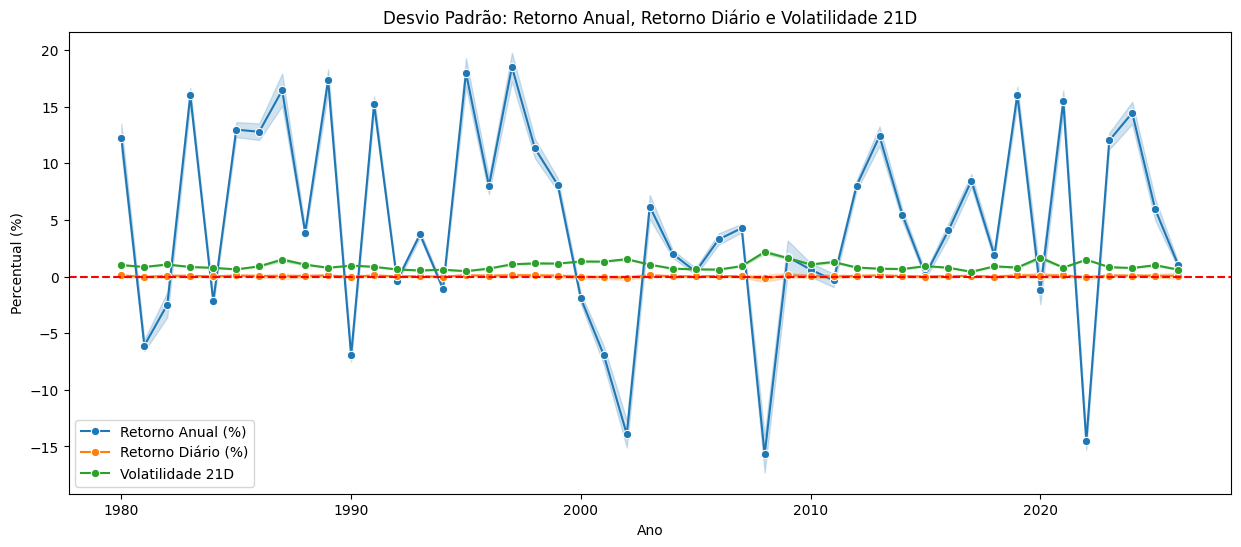

In [12]:
# Qual gráfico seria interessante usar pra mostrar o desvio padrão?

plt.figure(figsize=(15, 6))

# Retorno anual
sns.lineplot(x='Year', y='Annual_Return_Pct', data=df, label='Retorno Anual (%)', marker='o')

# Retorno diário
sns.lineplot(x='Year', y='Daily_Return_Pct', data=df, label='Retorno Diário (%)', marker='o')

# Volatilidade 21D
sns.lineplot(x='Year', y='Volatility_21D', data=df, label='Volatilidade 21D', marker='o')

plt.title('Desvio Padrão: Retorno Anual, Retorno Diário e Volatilidade 21D')
plt.xlabel('Ano')
plt.ylabel('Percentual (%)')
plt.axhline(0, color='red', linestyle='--')  # linha de referência no zero
plt.legend()
plt.show()

## Histograma

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers). O histograma é uma ferramenta visual fundamental para representar essa distribuição, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

### *Retorno diário e Anual*



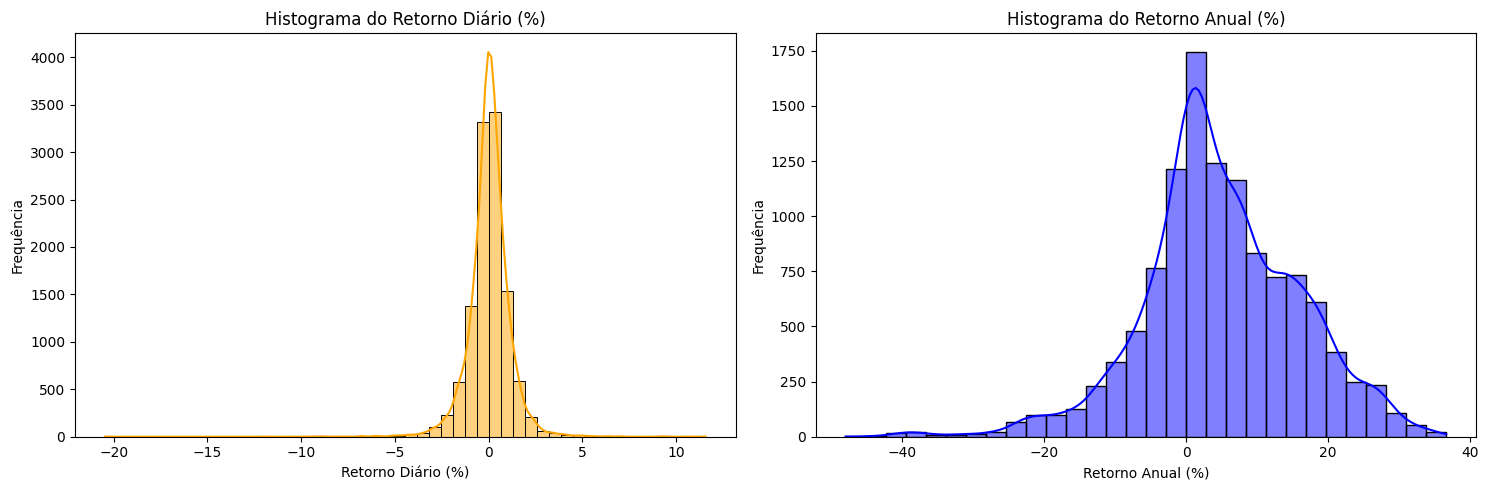

In [13]:
plt.figure(figsize=(15, 5))

# Histograma do Retorno Diário
plt.subplot(1, 2, 1)
sns.histplot(df['Daily_Return_Pct'], bins=50, kde=True, color='orange')
plt.title('Histograma do Retorno Diário (%)')
plt.xlabel('Retorno Diário (%)')
plt.ylabel('Frequência')

# Histograma do Retorno Anual
plt.subplot(1, 2, 2)
sns.histplot(df['Annual_Return_Pct'], bins=30, kde=True, color='blue')
plt.title('Histograma do Retorno Anual (%)')
plt.xlabel('Retorno Anual (%)')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

A análise dos histogramas evidencia que os retornos diários se concentram fortemente em torno de zero, refletindo pequenas variações na maioria dos dias, com raros eventos extremos em períodos de crise. Já os retornos anuais apresentam maior dispersão, com concentração próxima de zero em anos de ganhos ou perdas modestos, mas também uma cauda à direita, indicando a ocorrência de anos com ganhos expressivos. Essa assimetria positiva explica o crescimento acumulado do índice ao longo das décadas: embora muitos anos tenham retornos modestos, os anos de forte valorização superam os de queda, sustentando a trajetória ascendente do S&P 500 no longo prazo.

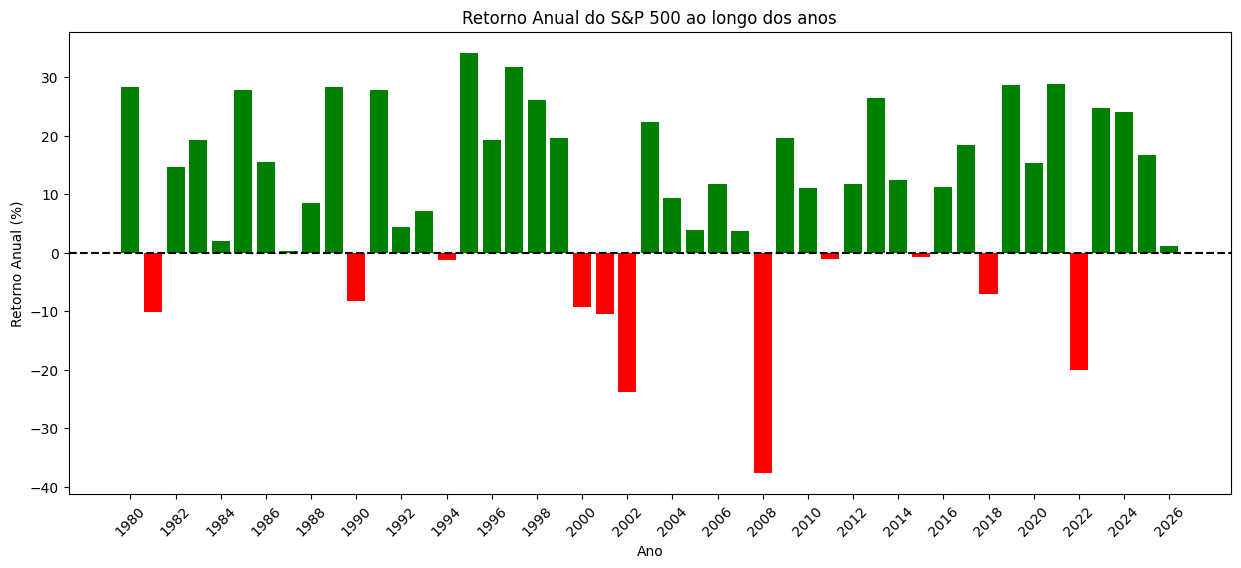

In [14]:
# Gráfico em colunas do Retorno Anual

# Selecionar apenas o último valor de cada ano
df_last_day = df.groupby('Year').tail(1)

plt.figure(figsize=(15, 6))

# Definir cores: verde para positivo, vermelho para negativo
colors = ['green' if val >= 0 else 'red' for val in df_last_day['Annual_Return_Pct']]

# Gráfico em colunas com cores condicionais
plt.bar(df_last_day['Year'], df_last_day['Annual_Return_Pct'], color=colors)

plt.title('Retorno Anual do S&P 500 ao longo dos anos')
plt.xlabel('Ano')
plt.ylabel('Retorno Anual (%)')

# Linha de referência no zero
plt.axhline(0, color='black', linestyle='--')

# Mostrar apenas ano sim, ano não no eixo x
plt.xticks(df_last_day['Year'][::2], rotation=45)

plt.show()

O gráfico acima evidencia a razão da cauda à direita observada no histograma dos retornos anuais. Nota-se a predominância de anos com retornos positivos em relação aos anos de perdas, o que reforça a tendência estrutural de crescimento do índice no longo prazo, apesar das crises pontuais.

## Boxplot

Um boxplot é um gráfico estatístico usado para representar a distribuição de um conjunto de dados. Ele mostra a mediana, os quartis (superior e inferior), os valores mínimos e máximos dentro de um intervalo considerado normal, além de destacar possíveis valores atípicos (outliers). Esse tipo de visualização facilita a identificação da dispersão, da simetria e da concentração dos dados em torno de determinados pontos.




### Retornos anuais e diários e volatilidade


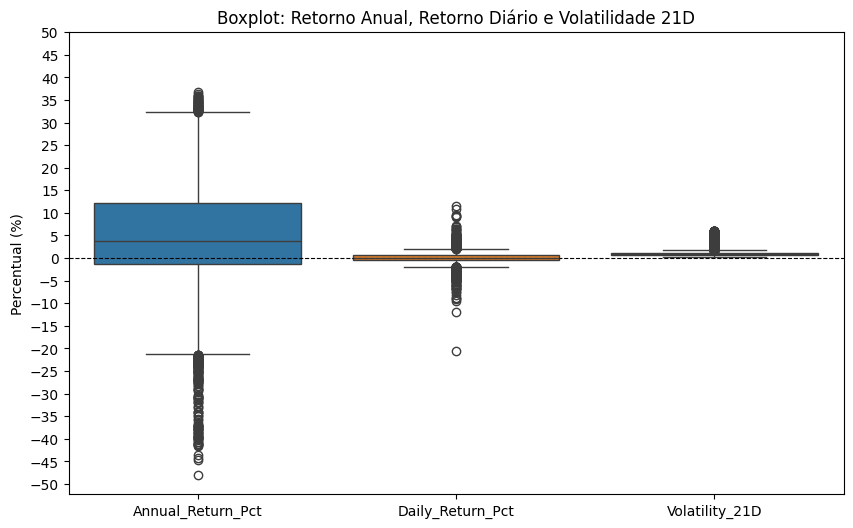

In [15]:
# Boxplot do retornos anuais e diários e da volatilidade
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['Annual_Return_Pct', 'Daily_Return_Pct', 'Volatility_21D']])
plt.title('Boxplot: Retorno Anual, Retorno Diário e Volatilidade 21D')
plt.ylabel('Percentual (%)')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.yticks(range(-50, 51, 5))  # ajusta o eixo y conforme o intervalo dos dados
plt.show()

O boxplot evidencia que a mediana dos retornos anuais se situa em torno de 4 a 5%, refletindo o crescimento médio do índice ao longo das décadas. Nota-se uma concentração de valores positivos acima de 5%, acompanhada de alguns outliers de forte valorização e outros de perdas mais distribuídas. Em contraste, os retornos diários e a volatilidade de 21 dias apresentam caixas estreitas e concentradas em torno de zero, reforçando que o risco de curto prazo é limitado, mas o acumulado anual pode variar de forma significativa

## Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

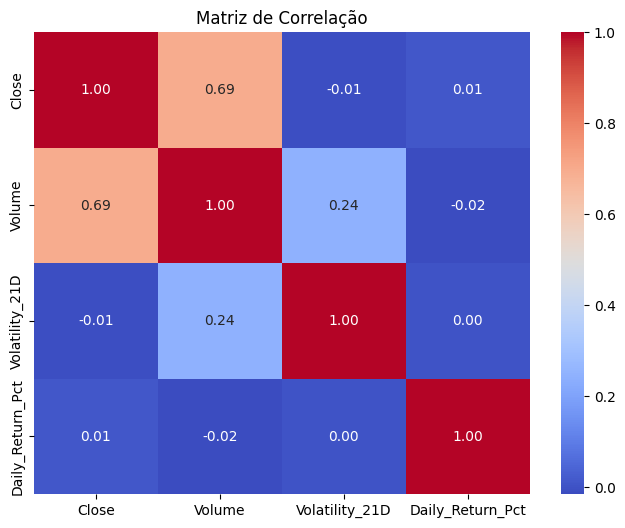

In [16]:
# Selecionar variáveis de interesse
corr_vars = df[['Close', 'Volume', 'Volatility_21D', 'Daily_Return_Pct']]

# Calcular matriz de correlação
corr_matrix = corr_vars.corr()

# Plotar heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação')
plt.show()

A matriz de correlação mostra que o retorno diário e o nível de fechamento do índice não apresentam relação significativa, reforçando que variações percentuais independem do preço absoluto. Da mesma forma, o fechamento e a volatilidade não se correlacionam de forma relevante. Já o volume de negociação apresenta correlação positiva moderada com a volatilidade, indicando maior atividade em períodos de instabilidade. Por fim, observa-se uma correlação relativamente forte entre volume e fechamento, refletindo o crescimento estrutural do mercado e o aumento da liquidez ao longo do tempo.

## Tratamento de Valores Nulos

O dataset Iris original não possui valores nulos. No entanto, o tratamento de valores nulos é crucial e pode envolver imputação (preenchimento com média, mediana, moda) ou remoção de linhas/colunas.

In [17]:
# Verificar a presença de valores nulos no dataset original
print("Valores nulos no dataset S&P 500:")
df.isnull().sum()

Valores nulos no dataset S&P 500:


,0
Date,0
Year,0
Month,0
Quarter,0
DayOfWeek,0
Open,0
High,0
Low,0
Close,0
Volume,0


Para garantir a consistência das análises, serão removidas as primeiras linhas do dataset que apresentam valores nulos em indicadores técnicos como médias móveis, volatilidade, RSI e Bandas de Bollinger. Esses valores nulos não representam erros de coleta ou inconsistências, mas decorrem da própria metodologia de cálculo, que exige uma janela de observações anteriores. Como se tratam de registros iniciais, referentes a períodos muito antigos, sua exclusão não compromete a análise, permitindo trabalhar apenas com dados completos e relevantes para os objetivos do estudo.

In [19]:
# Remove as linhas com valores nulos
indicators = ['Daily_Return_Pct','Volatility_21D','SMA_7','SMA_21','SMA_50','SMA_200','RSI_14','BB_Upper','BB_Mid','BB_Lower','BB_Width']
#df_clean = df.dropna(subset=indicators)

print("Valores nulos no dataset S&P 500 limpo:")
#df_clean.isnull().sum()
df = df.dropna(subset=indicators)
df.isnull().sum()


Valores nulos no dataset S&P 500 limpo:


,0
Date,0
Year,0
Month,0
Quarter,0
DayOfWeek,0
Open,0
High,0
Low,0
Close,0
Volume,0


In [20]:
#Verificando informações atuais do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11416 entries, 199 to 11614
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   11416 non-null  object 
 1   Year                   11416 non-null  int64  
 2   Month                  11416 non-null  int64  
 3   Quarter                11416 non-null  int64  
 4   DayOfWeek              11416 non-null  object 
 5   Open                   11416 non-null  float64
 6   High                   11416 non-null  float64
 7   Low                    11416 non-null  float64
 8   Close                  11416 non-null  float64
 9   Volume                 11416 non-null  int64  
 10  Daily_Return_Pct       11416 non-null  float64
 11  Cumulative_Return_Pct  11416 non-null  float64
 12  Annual_Return_Pct      11416 non-null  float64
 13  Volatility_21D         11416 non-null  float64
 14  SMA_7                  11416 non-null  float64
 15  SMA_2

# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

In [21]:
# Queremos saber se teremos um dia com retorno diário maior que zero ou negativo
# Criar target binário: 1 se retorno diário >= 0, 0 se < 0
df['Target'] = (df['Daily_Return_Pct'] >= 0).astype(int)

# Selecionar features
X = df[['Close', 'Volume', 'Volatility_21D', 'SMA_21', 'RSI_14', 'MACD', 'MACD_Signal']]
y = df['Target']

In [22]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [23]:
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

Dimensões de X_train: (7991, 7)
Dimensões de X_test: (3425, 7)
Dimensões de y_train: (7991,)
Dimensões de y_test: (3425,)


## Normalização

A normalização escala os dados para um intervalo fixo, geralmente entre 0 e 1. É útil quando o algoritmo de machine learning assume que as características estão em uma escala semelhante.



In [24]:
# Inicializar o MinMaxScaler
scaler_norm = MinMaxScaler()

In [25]:
# Aprende min e max APENAS de X_train
scaler_norm.fit(X_train)
X_train_normalized = scaler_norm.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_normalized = scaler_norm.transform(X_test)

In [26]:
# Exibir as primeiras linhas dos dados normalizados (como DataFrame para melhor visualização)
df_normalized = pd.DataFrame(X_train_normalized, columns=X_train.columns)

In [27]:
print("\nPrimeiras 5 linhas dos dados normalizados (treino):")
print(df_normalized.head())


Primeiras 5 linhas dos dados normalizados (treino):
      Close    Volume  Volatility_21D    SMA_21    RSI_14      MACD  \
0  0.049725  0.023510        0.061657  0.049932  0.451863  0.665339   
1  0.283479  0.321741        0.069190  0.278569  0.814931  0.739060   
2  0.176038  0.073301        0.162067  0.176055  0.515910  0.660155   
3  0.184348  0.446902        0.293646  0.177848  0.626734  0.663757   
4  0.040547  0.017745        0.144468  0.040896  0.473212  0.656347   

   MACD_Signal  
0     0.675416  
1     0.749664  
2     0.651131  
3     0.652907  
4     0.667382  


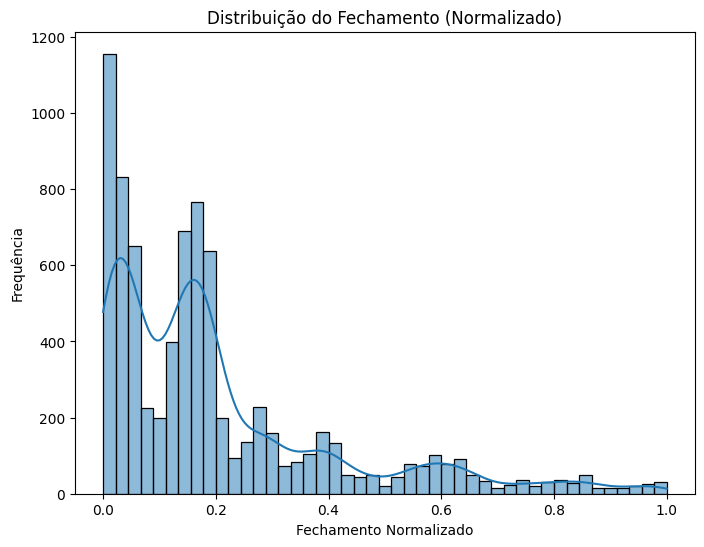

In [28]:
# Visualização da distribuição após a normalização (exemplo para uma característica)
#(exemplo: Close)
plt.figure(figsize=(8, 6))
sns.histplot(df_normalized['Close'], kde=True)
plt.title('Distribuição do Fechamento (Normalizado)')
plt.xlabel('Fechamento Normalizado')
plt.ylabel('Frequência')
plt.show()

O histograma de *Close* após a normalização mostra que os valores foram escalados para o intervalo de 0 a 1.

A maior parte dos valores ficou próxima de 0, indicando que muitos preços de fechamento estavam próximos do mínimo histórico do período de treino.

Há uma cauda longa até 1, mostrando que poucos valores estavam próximos do máximo histórico.

## Padronização

A padronização (ou Z-score scaling) transforma os dados para ter média 0 e desvio padrão 1. É útil para algoritmos que são sensíveis à escala das características, como SVMs ou redes neurais.

In [29]:
# Inicializar o StandardScaler
scaler_std = StandardScaler()

In [30]:
# Aprende média e desvio padrão APENAS de X_train
scaler_std.fit(X_train)
X_train_standardized = scaler_std.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_standardized = scaler_std.transform(X_test)

In [31]:
# Exibir as primeiras linhas dos dados padronizados (como DataFrame para melhor visualização)
df_standardized = pd.DataFrame(X_train_standardized, columns=X_train.columns)

In [32]:
print("\nPrimeiras 5 linhas dos dados padronizados (treino):")
print(df_standardized.head())


Primeiras 5 linhas dos dados padronizados (treino):
      Close    Volume  Volatility_21D    SMA_21    RSI_14      MACD  \
0 -0.723443 -0.937953       -0.644836 -0.721454 -0.843810 -0.195903   
1  0.380199  0.701403       -0.568298  0.354945  1.463703  0.965167   
2 -0.127068 -0.664256        0.375376 -0.127681 -0.436754 -0.277552   
3 -0.087833  1.389402        1.712276 -0.119237  0.267599 -0.220813   
4 -0.766777 -0.969647        0.196558 -0.763995 -0.708125 -0.337520   

   MACD_Signal  
0    -0.196170  
1     0.872199  
2    -0.545622  
3    -0.520062  
4    -0.311780  


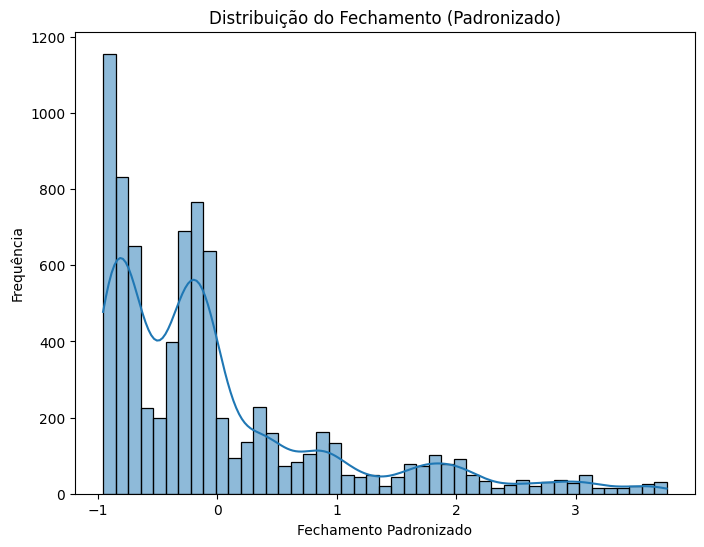

In [33]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['Close'], kde=True)
plt.title('Distribuição do Fechamento (Padronizado)')
plt.xlabel('Fechamento Padronizado')
plt.ylabel('Frequência')
plt.show()

O gráfico mostra que o fechamento, quando padronizado, tem distribuição não simétrica, com predominância de valores próximos ou abaixo da média e uma cauda longa para valores acima. Isso é esperado em séries financeiras de longo prazo, pois o crescimento estrutural do mercado faz com que os preços mais recentes fiquem bem acima da média histórica.

## Outras Transformações e Etapas de Pré-Processamento

Outras etapas de pré-processamento incluem a seleção de características, redução de dimensionalidade (como PCA) ou criação de novas características (feature engineering). O que você faria a mais?



# Respondendo nossas hipóteses

Quais visualizações, tabelas e células descritivas respondem às hipóteses que você levantou?



## Hipótese 1

Existe correlação entre o volume das transações e o retorno diário?

A análise mostra que o volume reflete períodos de maior atividade no mercado, mas não apresenta correlação direta e consistente com o retorno diário. O volume pode indicar momentos de volatilidade ou eventos relevantes, mas não é um preditor isolado da direção dos retornos.


## Hipótese 2

Um investidor que aplica na S&P500 no longo prazo tende a ter mais ganhos que perdas?

Sim. A série histórica do índice demonstra que, apesar de crises pontuais, o S&P500 apresenta tendência de crescimento no longo prazo. Investidores que mantêm posições por períodos extensos tendem a acumular ganhos, já que o mercado se recupera e supera quedas anteriores.

## Hipótese 3

A covid-19 teve um grande impacto na bolsa? Ela foi a pior crise do mercado historicamente?

A pandemia de covid-19 gerou forte impacto inicial, com quedas abruptas em 2020. No entanto, historicamente, crises como a de 2008 (subprime) e a de 2000–2002 (bolha da internet) tiveram efeitos mais prolongados e profundos sobre o mercado. A recuperação pós-covid foi relativamente rápida em comparação a essas crises anteriores.

# Conclusão

A análise e o pré-processamento do dataset financeiro evidenciam a relevância de compreender tanto os indicadores técnicos quanto o contexto histórico dos dados. A normalização e padronização permitiram alinhar variáveis em escalas distintas, preparando o conjunto para modelagem preditiva. As hipóteses levantadas reforçam que o volume de transações não é suficiente para prever retornos diários, que o investimento de longo prazo no S&P500 tende a ser vantajoso, e que, embora a covid-19 tenha causado forte impacto inicial, crises anteriores como a de 2008 e a de 2000–2002 foram mais severas.

Conclui-se que o pré-processamento realizado foi adequado para estruturar análises consistentes e que os resultados obtidos confirmam a importância de unir técnicas estatísticas com conhecimento de mercado. O trabalho abre espaço para futuras investigações, como a criação de novas variáveis e o uso de técnicas avançadas de modelagem, mas já demonstra que a preparação cuidadosa dos dados é essencial para extrair conclusões sólidas e fundamentadas.